# V1-S04 — Enrichment coverage report

Reads the enrichment views attached to `data/v1/papers.duckdb` (created by
`scifield enrich`). Produces a coverage matrix per-journal × per-era for
OpenAlex match, outgoing references resolved, OA DOI, author OpenAlex IDs,
ORCIDs, and institution ROR IDs.

Re-execute after a fresh enrichment run:
```bash
uv run scifield enrich --config v1
uv run jupyter nbconvert --execute notebooks/02_coverage_report.ipynb \
    --to notebook --inplace
```

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

_probe = Path.cwd()
DUCKDB_PATH = None
for _ in range(5):
    candidate = _probe / "data" / "v1" / "papers.duckdb"
    if candidate.exists():
        DUCKDB_PATH = candidate
        break
    _probe = _probe.parent
assert (
    DUCKDB_PATH is not None
), "missing data/v1/papers.duckdb; run `uv run scifield harvest` first."

con = duckdb.connect(str(DUCKDB_PATH), read_only=True)

view_names = {
    r[0]
    for r in con.execute("SELECT view_name FROM duckdb_views() WHERE schema_name='main'").fetchall()
}

ENRICH_VIEWS = {
    "openalex_works",
    "references_out",
    "authorships",
    "institutions",
    "paper_institutions",
    "semantic_scholar",
    "citation_intents",
    "enrichment_failed",
}
available = sorted(ENRICH_VIEWS & view_names)
missing = sorted(ENRICH_VIEWS - view_names)
print(f"enrichment views attached: {available}")
if missing:
    print(f"missing views (run `scifield enrich`): {missing}")

enrichment views attached: ['authorships', 'citation_intents', 'enrichment_failed', 'institutions', 'openalex_works', 'paper_institutions', 'references_out', 'semantic_scholar']


## Overall coverage

Plan acceptance targets:
- OpenAlex match ≥ 90%
- Post-2000 outgoing references resolved ≥ 80%
- Pre-2000 OpenAlex coverage: reported, no threshold (governs the V1-S10 era restriction rule)

In [2]:
n_papers = con.execute("SELECT COUNT(DISTINCT pmid) FROM papers WHERE pmid <> ''").fetchone()[0]

if "openalex_works" in view_names:
    n_oa = con.execute(
        "SELECT COUNT(DISTINCT pmid) FROM openalex_works WHERE openalex_id <> ''"
    ).fetchone()[0]
else:
    n_oa = 0

if "references_out" in view_names:
    n_with_refs = con.execute("SELECT COUNT(DISTINCT citing_pmid) FROM references_out").fetchone()[
        0
    ]
    n_post2000 = con.execute(
        "SELECT COUNT(DISTINCT pmid) FROM papers WHERE pmid <> '' AND year >= 2000"
    ).fetchone()[0]
    n_with_refs_post2000 = con.execute(
        "SELECT COUNT(DISTINCT r.citing_pmid) FROM references_out r "
        "JOIN papers p ON p.pmid = r.citing_pmid "
        "WHERE p.year >= 2000"
    ).fetchone()[0]
else:
    n_with_refs = 0
    n_post2000 = 1
    n_with_refs_post2000 = 0

pct_oa = n_oa / n_papers if n_papers else 0.0
pct_refs_post2000 = n_with_refs_post2000 / n_post2000 if n_post2000 else 0.0

print(f"papers (V1-S03):            {n_papers:>9,}")
print(f"OpenAlex match:             {n_oa:>9,}  ({pct_oa:.1%})")
print(f"refs resolved (overall):    {n_with_refs:>9,}")
print(f"refs resolved (post-2000):  {n_with_refs_post2000:>9,}  ({pct_refs_post2000:.1%})")
print()
print(f"PASS OpenAlex≥90%?           {'YES' if pct_oa >= 0.90 else 'NO'}")
print(f"PASS refs(post2000)≥80%?     {'YES' if pct_refs_post2000 >= 0.80 else 'NO'}")

papers (V1-S03):              121,908
OpenAlex match:               118,317  (97.1%)
refs resolved (overall):      110,158
refs resolved (post-2000):     98,595  (91.8%)

PASS OpenAlex≥90%?           YES
PASS refs(post2000)≥80%?     YES


## Coverage matrix — journal × era × source

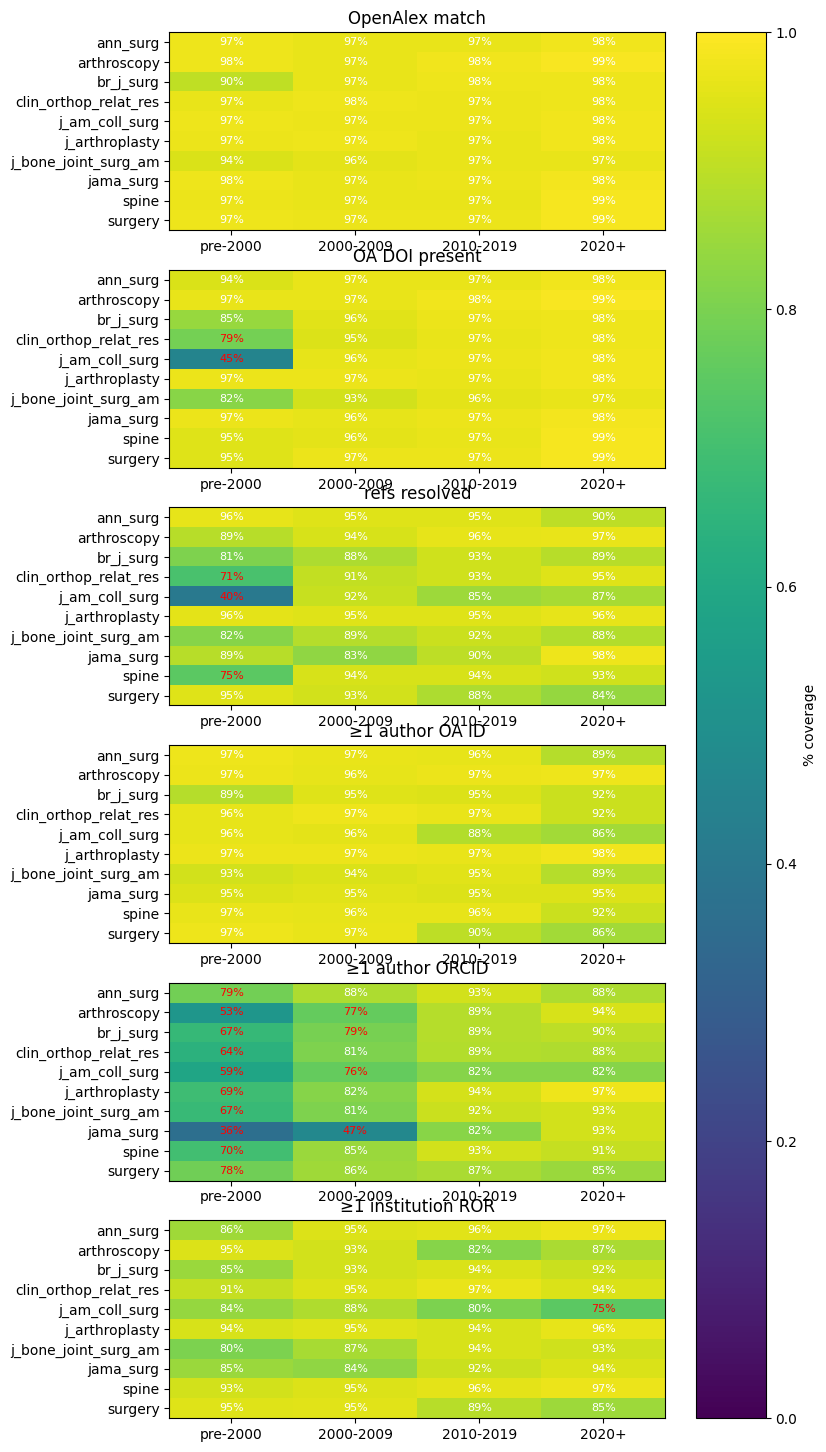

In [3]:
ERA_CASE = """CASE
    WHEN year < 2000 THEN 'pre-2000'
    WHEN year BETWEEN 2000 AND 2009 THEN '2000-2009'
    WHEN year BETWEEN 2010 AND 2019 THEN '2010-2019'
    WHEN year >= 2020 THEN '2020+'
    ELSE 'unknown'
END"""


def coverage(metric_sql: str) -> pd.DataFrame:
    q = f"""
    SELECT journal_slug, {ERA_CASE} AS era,
           AVG(CASE WHEN {metric_sql} THEN 1.0 ELSE 0.0 END) AS pct
    FROM papers
    GROUP BY 1, 2
    """
    df = con.execute(q).fetch_df()
    return df.pivot(index="journal_slug", columns="era", values="pct").reindex(
        columns=["pre-2000", "2000-2009", "2010-2019", "2020+"]
    )


metrics: dict[str, str] = {}
if "openalex_works" in view_names:
    metrics["OpenAlex match"] = (
        "EXISTS (SELECT 1 FROM openalex_works oa "
        "WHERE oa.pmid = papers.pmid AND oa.openalex_id <> '')"
    )
    metrics["OA DOI present"] = (
        "EXISTS (SELECT 1 FROM openalex_works oa "
        "WHERE oa.pmid = papers.pmid AND oa.oa_doi <> '')"
    )
if "references_out" in view_names:
    metrics["refs resolved"] = (
        "EXISTS (SELECT 1 FROM references_out r WHERE r.citing_pmid = papers.pmid)"
    )
if "authorships" in view_names:
    metrics["≥1 author OA ID"] = (
        "EXISTS (SELECT 1 FROM authorships a "
        "WHERE a.pmid = papers.pmid AND a.author_oa_id <> '')"
    )
    metrics["≥1 author ORCID"] = (
        "EXISTS (SELECT 1 FROM authorships a "
        "WHERE a.pmid = papers.pmid AND a.author_orcid <> '')"
    )
if {"paper_institutions", "institutions"}.issubset(view_names):
    metrics["≥1 institution ROR"] = (
        "EXISTS (SELECT 1 FROM paper_institutions pi "
        "JOIN institutions i ON i.institution_canonical_id = pi.institution_canonical_id "
        "WHERE pi.pmid = papers.pmid AND i.ror_id <> '')"
    )

if not metrics:
    print("no enrichment views attached — run `uv run scifield enrich --config v1`")
else:
    n_metrics = len(metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(8, max(3 * n_metrics, 4)), squeeze=False)
    for ax, (label, sql) in zip(axes[:, 0], metrics.items(), strict=False):
        pivot = coverage(sql)
        im = ax.imshow(pivot.values, vmin=0, vmax=1, aspect="auto", cmap="viridis")
        ax.set_xticks(range(pivot.shape[1]))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(pivot.shape[0]))
        ax.set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                if pd.isna(v):
                    continue
                color = "red" if v < 0.80 else "white"
                ax.text(j, i, f"{v:.0%}", ha="center", va="center", color=color, fontsize=8)
        ax.set_title(label)
    plt.colorbar(im, ax=axes[:, 0].tolist(), label="% coverage")
    plt.show()

## Pre-2000 OpenAlex coverage (risk register input)

Decision rule per plan §5 / §6 row 1: **if pre-2000 OpenAlex coverage <60%,
restrict V1-S10 novelty/CD analyses to post-2000.** This cell prints the
number that drives that decision.

In [4]:
if "openalex_works" not in view_names:
    print("no openalex_works view — run `uv run scifield enrich --config v1`")
else:
    n_pre = con.execute(
        "SELECT COUNT(DISTINCT pmid) FROM papers WHERE pmid <> '' AND year < 2000"
    ).fetchone()[0]
    n_pre_oa = con.execute(
        "SELECT COUNT(DISTINCT oa.pmid) FROM openalex_works oa "
        "JOIN papers p ON p.pmid = oa.pmid "
        "WHERE p.year < 2000 AND oa.openalex_id <> ''"
    ).fetchone()[0]
    if n_pre == 0:
        print("no pre-2000 papers in corpus.")
    else:
        pct = n_pre_oa / n_pre
        print(f"pre-2000 OpenAlex coverage: {pct:.1%} of {n_pre:,} papers")
        if pct < 0.60:
            print("WARN coverage <60% — apply post-2000 restriction in V1-S10 per risk register.")
        else:
            print("OK coverage ≥60% — pre-2000 retained for V1-S10.")

pre-2000 OpenAlex coverage: 95.8% of 14,452 papers
OK coverage ≥60% — pre-2000 retained for V1-S10.


In [5]:
con.close()